# Atividade de Construção I — A ficha que você teria de defender

**Computação Cognitiva · Ciência de Dados e Negócios · ESPM · 2026.2 · Prof. André Insardi**

**Integrantes**

- <<INTEGRANTES: Nome Sobrenome, Nome Sobrenome, ...>>

> Preencha os nomes acima **e** a lista `INTEGRANTES` na célula de setup (ou regenere
> com `python scripts/build_notebook.py --integrantes "Nome Sobrenome" ...`). O nome
> dos três arquivos de entrega (`AtividadeI_<sobrenomes>`) é derivado dessa lista.

**Declaração de uso de IA (Seção 7).** Usamos assistentes de IA para escrever partes do
código do pacote `ficha` e revisar textos. Todas as decisões de projeto, os números e
as conclusões foram verificados pelo grupo.

**Como ler este notebook.** Toda a lógica (limpeza, seleção, prompt, parse, auditoria,
custo, relatório) vive no pacote testado `src/ficha`; aqui só orquestramos e
mostramos resultados (ADR 0001). Há dois modos:

- `MODO = "ensaio"`: `FakeLLM` determinístico + PDFs sintéticos gerados na hora —
  roda em segundos, sem GPU nem rede, e prova que o pipeline inteiro funciona.
  **Os números do modo ensaio não são resultados da atividade.**
- `MODO = "real"`: os 19 PDFs em `data/raw` + Qwen2.5-3B-Instruct na T4 do Colab
  (ou o backend declarado). É este que gera a entrega.

## 1. Setup

**No Colab, antes de qualquer célula:** *Ambiente de execução → Alterar tipo → GPU T4*
(a troca reinicia a sessão). Depois:

1. suba `ficha.zip` (gerado por `make colab-zip`) para `/content/`;
2. suba os 19 PDFs para `/content/ficha/data/raw/` (ou aponte `RAW_DIR` para o Drive);
3. se for usar API, cadastre a chave nos **Secrets** do Colab (ícone de chave) com o nome
   `ANTHROPIC_API_KEY` — ela é lida para o ambiente **sem ser impressa**.

Sementes fixas em `random`, `numpy` e `torch` (Seção 7, Reprodutibilidade).

In [1]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

INTEGRANTES = ['<<INTEGRANTES: Nome Sobrenome, Nome Sobrenome, ...>>']
MODO = os.environ.get("FICHA_MODO", "ensaio")  # troque para "real" na entrega
BACKEND_REAL = "qwen_local"  # ou "anthropic" / "openai_compat" (declare no relatório)
RAW_DIR = None  # ex.: Path("/content/drive/MyDrive/artigos") — None = data/raw
# Reutiliza execuções já gravadas em data/runs (mesma configuração) em vez de chamar
# o modelo de novo — ver seção 6. FICHA_REUSAR=0 força reexecutar tudo.
REUSAR_EXECUCOES = os.environ.get("FICHA_REUSAR", "1") == "1"

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    ROOT = Path("/content/ficha")
    if not ROOT.exists() and Path("/content/ficha.zip").exists():
        shutil.unpack_archive("/content/ficha.zip", ROOT)
    extras = "local,embeddings,api"
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"ficha[{extras}] @ file://{ROOT}"],
        check=True,
    )
else:
    cwd = Path.cwd()
    ROOT = Path(os.environ.get("FICHA_ROOT", cwd.parent if cwd.name == "notebooks" else cwd))
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

if IN_COLAB:  # chaves: Secrets do Colab → ambiente, nunca impressas
    from google.colab import userdata

    for nome in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY"):
        try:
            valor = userdata.get(nome)
        except Exception:
            valor = None
        if valor:
            os.environ[nome] = valor

from ficha.extract import set_seeds
from ficha.llm.qwen_local import describe_gpu

set_seeds(42)
print(f"MODO={MODO} · reusar execuções={REUSAR_EXECUCOES} · Colab={IN_COLAB} · raiz={ROOT}")
print("GPU:", describe_gpu() or "nenhuma (ok no modo ensaio; no modo real use a T4)")
print("Chaves no ambiente (só presença):",
      {n: bool(os.environ.get(n)) for n in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY")})

MODO=ensaio · reusar execuções=True · Colab=False · raiz=/Users/joaomascena/Developer/studies/Atividade Andre


GPU: nenhuma (ok no modo ensaio; no modo real use a T4)
Chaves no ambiente (só presença): {'ANTHROPIC_API_KEY': False, 'OPENAI_API_KEY': False}


## 2. Configuração declarada

Tudo o que o relatório precisa declarar vem de `ficha.config.Settings` (variáveis
`FICHA_*`, `.env` ou Secrets): modelo, temperatura, semente, parâmetros de seleção e a
**premissa de preço** usada na Seção 4.5. Nenhum segredo é impresso.

In [2]:
import json

import pandas as pd
from IPython.display import Image, display

from ficha.config import Settings, get_settings
from ficha.llm import FakeBehavior, build_client

pd.set_option("display.max_colwidth", 120)
if MODO == "ensaio":
    DATA_DIR = ROOT / "data" / "outputs" / "ensaio"
    shutil.rmtree(DATA_DIR, ignore_errors=True)  # ensaio sempre do zero
    settings = get_settings(data_dir=DATA_DIR, model_backend="fake")
    # Erros simulados para a auditoria ter o que encontrar (ver ficha.llm.fake).
    client = build_client(settings, behavior=FakeBehavior(
        broken_json_rate=0.25, invent_trecho_rate=0.2,
        invent_limitacao_rate=0.4, unstable_rate=0.3,
    ))
else:
    settings = get_settings(data_dir=ROOT / "data", model_backend=BACKEND_REAL)
    client = build_client(settings)
settings.ensure_dirs()
FIG_DIR = settings.outputs_dir / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)
count_tokens = client.count_tokens  # tokenizador real no Qwen; ~4 chars/token no fake

print(json.dumps(settings.declaracao(), ensure_ascii=False, indent=2))
print("cliente:", client.model_name)

{
  "modelo": "fake:Qwen/Qwen2.5-3B-Instruct",
  "quantize_4bit": false,
  "temperatura": 0.0,
  "temperatura_alternativa": 0.7,
  "seed": 42,
  "embedding_model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "premissa_preco_usd_por_mtok": {
    "entrada": 3.0,
    "saida": 15.0,
    "fonte": "Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09"
  }
}
cliente: fake/deterministic-v1


## 3. Ingestão e limpeza do texto

`ficha.ingest` extrai o texto página a página com `pymupdf` e aplica uma limpeza
determinística e conservadora (Seção 4.1, último parágrafo): remove cabeçalhos e
rodapés repetidos e números de página soltos, desfaz a **hifenização de fim de linha**
(com vocabulário do próprio artigo para não quebrar compostos legítimos como
*state-of-the-art*), reconstrói parágrafos e normaliza espaços. O resultado fica em
cache (`data/processed`, com `sha256`) para que todas as execuções usem o mesmo texto.

In [3]:
from ficha.ingest import load_or_ingest
from ficha.ingest.synthetic import generate_synthetic_corpus
from ficha.report.overview import corpus_frame

raw_dir = Path(RAW_DIR) if RAW_DIR else settings.raw_dir
if MODO == "ensaio":
    artigos = generate_synthetic_corpus(raw_dir, n=6, seed=settings.seed)
    # Gabarito conhecido: quais artigos declaram limitação (null esperado nos demais).
    GABARITO_LIMITACAO = {a.arquivo: a.has_limitations for a in artigos}
else:
    GABARITO_LIMITACAO = None  # sem gabarito: a auditoria usa a heurística declarada

pdfs = sorted(raw_dir.glob("*.pdf"))
assert pdfs, f"Nenhum PDF em {raw_dir}: suba os artigos antes de continuar."
docs = [load_or_ingest(p, settings.processed_dir) for p in pdfs]
corpus = corpus_frame(docs, count_tokens)
display(corpus)
total = corpus.iloc[-1]
print(f"{len(docs)} artigos · {total.paginas} páginas · {total.caracteres:,} caracteres · "
      f"~{total.tokens:,} tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)")
meta = docs[0].metadata
print({k: meta.get(k) for k in ("n_chars_raw", "n_chars_clean", "empty_pages")})

,arquivo,paginas,caracteres,tokens
0,artigo_01.pdf,3,6852,1714
1,artigo_02.pdf,4,10425,2608
2,artigo_03.pdf,5,13879,3472
3,artigo_04.pdf,4,10567,2643
4,artigo_05.pdf,5,14839,3712
5,artigo_06.pdf,4,10678,2671
6,TOTAL,25,67240,16820


6 artigos · 25 páginas · 67,240 caracteres · ~16,820 tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)
{'n_chars_raw': 7085, 'n_chars_clean': 6852, 'empty_pages': []}


## 4. O que mandar para o modelo (Seção 4.1)

Quatro estratégias, todas com a mesma interface (`ContextSelector`, ADR 0002):

| Estratégia | O que envia | Risco |
|---|---|---|
| `first_pages` | as 3 primeiras páginas | limitações e métricas costumam ficar fora |
| `keyword` | seções achadas por título (*Methods*, *Results*, *Limitations*...) | depende do nome da seção |
| `semantic` | blocos de 1.200 caracteres (sobreposição de 200) mais próximos de 8 consultas em português, uma ou duas por campo da ficha | a limitação declarada raramente é o bloco mais parecido |
| `hybrid` | janelas após cabeçalhos de limitação + até 10 janelas em torno de pistas lexicais de limitação + os blocos do `semantic` + janelas de Discussion/Conclusion, num orçamento de 12.000 caracteres | parte do ganho é medição que se autoconfirma (ver abaixo) |

**Como chegamos à escolha.** A escolha é `semantic` (blocos de ~300 tokens, um parágrafo
típico; sobreposição de uma frase para não cortar a evidência; embedder multilíngue
porque as consultas são em português e os artigos em inglês), com `first_pages` como
alternativa da verificação 4.4c. Na execução real, `limitacao` veio `null` em 18 das
19 fichas. Antes de mexer no prompt, medimos se a **entrada** tinha a informação
(tabela a seguir): quase nenhuma frase de limitação chegava ao contexto. Construímos
então a estratégia **`hybrid`**, que prioriza janelas de limitação, e a rodamos como
**experimento**: ela corrige a entrada, mas — como mostra a comparação a três da seção
8c — não muda a saída. Pelo critério declarado da 4.4c, a final continua `semantic`.
A busca vetorial aqui **não é o produto** — é só o modo de escolher o que entra no
prompt. Abaixo: o que cada estratégia envia para um artigo, e o custo em tokens de
cada uma no corpus inteiro.

In [4]:
from ficha.report.overview import selection_frame, strategy_summary
from ficha.select import SELECTOR_NAMES, HashingEmbedder, build_selector

if MODO == "ensaio" or importlib.util.find_spec("sentence_transformers") is None:
    embedder = HashingEmbedder()  # offline, determinístico
    if MODO == "real":
        print("ATENÇÃO: sentence-transformers ausente; usando HashingEmbedder (declare no relatório).")
else:
    embedder = None  # SentenceTransformer multilíngue das Settings
ESTRATEGIA = os.environ.get("FICHA_ESTRATEGIA", "semantic")  # principal (4.1, ADR 0002)
ESTRATEGIA_ALT = "first_pages"  # comparação 4.4c
nomes = dict.fromkeys([*SELECTOR_NAMES, ESTRATEGIA, ESTRATEGIA_ALT])
selectors = {nome: build_selector(nome, settings, embedder) for nome in nomes}

exemplo = docs[0]
for nome, sel in selectors.items():
    ctx = sel.select(exemplo)
    texto = ctx.render()
    print(f"=== {nome}: páginas {list(ctx.pages)} · {len(ctx.chunks)} trechos · "
          f"{len(texto):,} chars · ~{count_tokens(texto):,} tokens · params={ctx.params}")
    print(texto[:500].rstrip(), "[...]\n")

=== first_pages: páginas [1, 2, 3] · 3 trechos · 6,877 chars · ~1,719 tokens · params={'n_pages': 3, 'max_chars': None, 'truncated': False}
[p. 1]
Predicting Thirty-Day Hospital Readmission from Electronic Health Records

A. Researcher, B. Scientist and C. Analyst · Institute of Data Studies

Abstract

This paper addresses the problem of forecasting hospital readmission within thirty days of discharge. Structured features are combined with TF-IDF representations of discharge notes and fed to a gradient boosted classifier tuned with five-fold cross-validation. Performance is measured by the area under the ROC curve (AUROC) and area u [...]

=== keyword: páginas [1, 2, 3] · 7 trechos · 4,504 chars · ~1,126 tokens · params={'window_chars': 1500, 'max_chars': 6000, 'sections': None, 'sections_found': ['Abstract', '3 Data', '4 Methods', '5 Results', '6 Limitations', '7 Discussion', '8 Conclusion'], 'fallback': None, 'sections_selected': ['Abstract', '6 Limitations', '4 Methods', '3 Data', '

In [5]:
selecao = selection_frame(docs, list(selectors.values()), count_tokens)
resumo_estrategias = strategy_summary(selecao)
display(resumo_estrategias)

,chunks_medios,caracteres_medios,tokens_medios,tokens_corpus,fracao_media_do_artigo
estrategia,,,,,
first_pages,3.0,9844,2461,14765,0.904
keyword,7.0,4312,1078,6467,0.410
semantic,4.8,6969,1742,10454,0.651
hybrid,4.5,10317,2579,15475,0.939


### A limitação declarada chega ao modelo?

O campo `limitacao` só pode ser preenchido se a frase em que os autores declaram a
limitação estiver no texto enviado. `ficha.select.recall_table` mede isso sobre o
**texto completo** de cada artigo: localiza as frases com declaração forte de
limitação ("a limitation of this study", "is limited by", "beyond the scope of this
work"...) e conta quantas chegam ao contexto de cada estratégia. É um diagnóstico
offline — não chama o modelo.

Se poucas chegam, o `null` em `limitacao` é sobretudo efeito da **seleção** (o modelo
não pode declarar o que não recebe), e não da abstenção do modelo.

In [6]:
import ficha.select as _select
from ficha.report.assemble import coverage_sentence, final_pages_share

recall_table = getattr(_select, "recall_table", None)
if recall_table is None:
    COBERTURA_LIMITACAO = ""
    print("recall_table ainda não existe no pacote.")
else:
    recall = recall_table(docs, selectors)
    display(recall)
    COBERTURA_LIMITACAO = coverage_sentence(recall, len(docs), final_pages_share(docs))
    if MODO == "real":  # revisão manual das frases detectadas (ADR 0002)
        COBERTURA_LIMITACAO += (
            " O detector é um regex ruidoso: na revisão manual só ~18 das frases são "
            "limitações admitidas pelos autores (precisão ≈ 30%, ADR 0002)."
        )
    print(COBERTURA_LIMITACAO)
    for d in docs[:4]:
        paginas = sorted({p for p, _ in _select.limitation_sentences(d)})
        print(f"  {d.arquivo[:30]}: frases de limitação nas páginas {paginas} de {d.n_pages}")

,estrategia,artigos_com_frases,artigos_cobertos,frases_total,frases_no_contexto,recall_frases,chars_medios
0,first_pages,3,3,3,3,1.000,9819
1,keyword,3,3,3,3,1.000,4251
2,semantic,3,2,3,2,0.667,6927
3,hybrid,3,3,3,3,1.000,10278


Das 3 frases em que os autores declaram limitação (3 dos 6 artigos têm ao menos uma), chegaram ao contexto enviado: first_pages 3 (100%; 3/3 artigos), keyword 3 (100%; 3/3 artigos), semantic 2 (67%; 2/3 artigos), hybrid 3 (100%; 3/3 artigos). Só 0% delas estão no último terço do artigo: estão espalhadas, e nenhuma estratégia de orçamento fixo cobre a maioria. O null em limitacao é sobretudo efeito da seleção (o modelo não declara o que não recebe), não da abstenção do modelo.
  artigo_01.pdf: frases de limitação nas páginas [2] de 3
  artigo_02.pdf: frases de limitação nas páginas [] de 4
  artigo_03.pdf: frases de limitação nas páginas [3] de 5
  artigo_04.pdf: frases de limitação nas páginas [] de 4


### Quanto orçamento dar ao `hybrid`?

O recall cresce com o orçamento quase linearmente. A curva abaixo reaproveita o mesmo
seletor (embeddings em cache) e muda só o teto de caracteres. Escolhemos **12k** por
custo e documentamos **20k** como alternativa (cobre todos os artigos que têm frases de
limitação, com mais tokens por chamada).

**Ressalva de circularidade (ADR 0002).** As pistas de seleção e o regex de medição
compartilham cinco termos (limitation, caveat, drawback, shortcoming, beyond the scope):
parte do ganho é medição que se autoconfirma. No controle com as frases sem nenhuma
pista, as pistas não ajudam com 12k (o ganho vem do orçamento); o ganho real aparece nas
limitações explícitas revisadas à mão. A validação final é a jusante: `limitacao`
preenchida com trecho fiel, comparando `semantic` × `hybrid` na seção 8c.

In [7]:
from ficha.report.assemble import budget_sentence
from ficha.report.overview import budget_curve

ORCAMENTO_HYBRID = ""
if recall_table is not None and "hybrid" in selectors:
    curva = budget_curve(docs, selectors["hybrid"], [12000, 16000, 20000, None])
    display(curva[["estrategia", "artigos_cobertos", "frases_no_contexto", "recall_frases",
                   "chars_medios", "tokens_por_artigo"]])
    ORCAMENTO_HYBRID = budget_sentence(curva, recall, docs)
    print(ORCAMENTO_HYBRID)
CIRCULARIDADE = (
    "Ressalva: as pistas de seleção e o regex de medição compartilham cinco termos; nas "
    "frases sem pista, as pistas não ajudam com 12k — o ganho real está nas limitações "
    "explícitas revisadas à mão (ADR 0002)."
) if MODO == "real" else ""

,estrategia,artigos_cobertos,frases_no_contexto,recall_frases,chars_medios,tokens_por_artigo
0,hybrid 12k,3,3,1.0,10278,2570
1,hybrid 16k,3,3,1.0,10278,2570
2,hybrid 20k,3,3,1.0,10278,2570
3,hybrid sem teto,3,3,1.0,10278,2570


Curva de orçamento do hybrid (recall das frases; artigos; tokens/artigo) — 12k: 100%, 3/3 artigos, ~2.570 tok · 16k: 100%, 3/3 artigos, ~2.570 tok · 20k: 100%, 3/3 artigos, ~2.570 tok · sem teto: 100%, 3/3 artigos, ~2.570 tok. Escolhemos 12k por custo: 1,1× mais barato que o artigo inteiro e +48% de caracteres sobre o semantic. 20k fica documentado como alternativa (3/3 artigos, +0% de tokens).


## 5. O prompt (Seção 4.2)

Cada técnica é um bloco com cabeçalho fixo, ligável/desligável por `PromptFeatures`
(ADR 0003): **papel** (`### PAPEL`, na mensagem de sistema), **instrução explícita** e
**formato de saída** com o schema JSON embutido, **delimitadores**
`<<<ARTIGO>>> ... <<<FIM_ARTIGO>>>` com o aviso de que nada ali dentro é ordem,
**few-shot** com dois exemplos — um deles com `limitacao: null` — e **abstenção**
("melhor `null` do que inventado"). A cadeia de raciocínio existe como variante
(`v_cot`, raciocínio num campo separado do JSON), mas não está na versão principal.

**Medição obrigatória:** `v_full` × `v_sem_fewshot` diferem **só** no few-shot.

**Temperatura 0,0.** Extração é tarefa de fidelidade: queremos a saída mais provável e
reprodutível (com semente fixa). A seção 8d mede o que muda com 0,7.

In [8]:
from ficha.prompts import build_prompt, describe_diff

builder = build_prompt("v_full")
rp = builder.render(selectors[ESTRATEGIA].select(exemplo))
print("Blocos presentes:", builder.markers_present(), "· template_sha:", builder.template_sha())
print("\n--- SYSTEM ---\n", rp.system)
print("\n--- USER (início) ---\n", rp.user[:2200], "\n[...]\n", rp.user[-400:])
print("\n", describe_diff("v_full", "v_sem_fewshot"))
print("\nTemperatura:", settings.temperature, "—", Settings.model_fields["temperature"].description)

Blocos presentes: ['### PAPEL', '### INSTRUÇÃO', '### FORMATO DE SAÍDA', '### REGRA DE ABSTENÇÃO', '### EXEMPLOS', '### ARTIGO'] · template_sha: e4ea67f171ac

--- SYSTEM ---
 ### PAPEL
Você é um assistente de pesquisa que prepara fichas de leitura de artigos científicos para uma tabela comparativa. Sua prioridade é a fidelidade ao texto: cada afirmação da ficha precisa poder ser defendida com um trecho do próprio artigo. Você nunca completa lacunas com conhecimento próprio nem com suposições plausíveis.

--- USER (início) ---
 ### INSTRUÇÃO
Leia o texto do artigo enviado abaixo (em inglês) e preencha a ficha, campo a campo:
- "problema": o que o trabalho tenta resolver, em uma frase.
- "dados": que dados usa — fonte, período e volume, quando informados.
- "metodo": a abordagem principal.
- "metrica": como o resultado é medido.
- "limitacao": a limitação que os PRÓPRIOS AUTORES declaram (não a sua opinião sobre o trabalho).
- "evidencia.trecho": um trecho COPIADO LITERALMENTE do texto e

## 6. Extração — matriz de execuções

Cada execução tem um `run_id` e grava **as saídas brutas** do modelo em
`data/runs/<run_id>/records.jsonl` (+ `manifest.json` com modelo, prompt, estratégia,
temperatura e semente). A saída passa por `parse_completion`: JSON validado pelo
schema (`FichaExtraida`, `extra="forbid"`); se vier malformado, tentamos reparos
registrados (cercas de código, vírgula final, aspas tipográficas) e o status fica
`repaired`; se nada funcionar, `failed` — o código trata e segue, não quebra.

| Execução | Prompt | Estratégia | Temperatura | Artigos | Serve para |
|---|---|---|---|---|---|
| a) principal | v_full | semantic | 0,0 | todos | tabela final |
| b) repetição | v_full | semantic | 0,0 | todos | 4.4b estabilidade |
| c) prompt alternativo | v_sem_fewshot | semantic | 0,0 | todos | 4.2 comparação |
| d) entrada alternativa | v_full | first_pages | 0,0 | todos | 4.4c efeito da entrada |
| e) temperatura | v_full | semantic | 0,7 | subconjunto | 4.4d temperatura |

**Reutilização (Seção 7, reprodutibilidade):** as saídas brutas gravadas são a fonte da
auditoria; com `REUSAR_EXECUCOES`, uma execução com a mesma configuração (estratégia,
variante, temperatura, repetição e artigos) é carregada de `data/runs` em vez de
refeita — reexecutar custa ~1 h de GPU e não muda a auditoria com decodificação gulosa
e seed fixa (a repetição da seção 8b mostra isso).

In [9]:
from ficha.extract import ExtractionRunner, RunResult, RunStore, reparse
from ficha.types import GenerationParams, ParseStatus

store = RunStore(settings.runs_dir)

def execucao_gravada(estrategia, variante, temperatura, repeticao, documentos):
    # run_id mais recente com a mesma configuração e os mesmos artigos, ou None.
    arquivos = sorted(d.arquivo for d in documentos)
    for run_id in reversed(store.list_runs()):
        try:
            m = store.manifest(run_id)
        except FileNotFoundError:
            continue
        if (m.get("status_execucao") == "concluida"
                and m["estrategia"]["nome"] == estrategia
                and m["prompt"]["variante"] == variante
                and float(m["temperatura"]) == float(temperatura)
                and m["repeticao"] == repeticao
                and m["n_docs"] == len(documentos)
                and sorted(m.get("arquivos", arquivos)) == arquivos):
            return run_id
    return None

def rodar(estrategia, variante, temperatura, repeticao, documentos):
    if REUSAR_EXECUCOES:
        run_id = execucao_gravada(estrategia, variante, temperatura, repeticao, documentos)
        if run_id is not None:
            res = RunResult(run_id, store.load(run_id), store.manifest(run_id))
            print(f"reutilizado: {run_id}: {res.status_counts()}")
            return res
    params = GenerationParams(temperature=temperatura, seed=settings.seed,
                              max_new_tokens=settings.max_new_tokens)
    runner = ExtractionRunner(client, selectors[estrategia], build_prompt(variante), params, store)
    res = runner.run(documentos, repetition=repeticao, show_progress=(MODO == "real"))
    print(f"{res.run_id}: {res.status_counts()}")
    return res

SUBCONJUNTO_T = docs[: max(3, len(docs) // 3)]  # 19 artigos → 6
execucoes = {
    "principal": rodar(ESTRATEGIA, "v_full", settings.temperature, 1, docs),
    "repeticao": rodar(ESTRATEGIA, "v_full", settings.temperature, 2, docs),
    "prompt_alt": rodar(ESTRATEGIA, "v_sem_fewshot", settings.temperature, 1, docs),
    "entrada_alt": rodar(ESTRATEGIA_ALT, "v_full", settings.temperature, 1, docs),
    "temperatura_alt": rodar(ESTRATEGIA, "v_full", settings.temperature_alt, 1, SUBCONJUNTO_T),
}
# Experimento de entrada (ADR 0002): a execução principal com a outra estratégia
# semântica. No modo real só é carregada se já estiver gravada — nunca reexecutada aqui.
EXPERIMENTO = "hybrid" if ESTRATEGIA != "hybrid" else "semantic"
extras = {}
if MODO == "ensaio" or execucao_gravada(EXPERIMENTO, "v_full", settings.temperature, 1, docs):
    extras["experimento"] = rodar(EXPERIMENTO, "v_full", settings.temperature, 1, docs)
display(pd.DataFrame([
    {"execucao": k, "run_id": r.run_id, **r.status_counts(),
     "json_valido_de_primeira": r.manifest["resumo"]["taxa_json_valido_de_primeira"]}
    for k, r in {**execucoes, **extras}.items()
]))

20260923-164428_semantic_v_full_t0.0_rep1: {'ok': 3, 'repaired': 3, 'failed': 0}
20260923-164428_semantic_v_full_t0.0_rep2: {'ok': 3, 'repaired': 3, 'failed': 0}
20260923-164428_semantic_v_sem_fewshot_t0.0_rep1: {'ok': 5, 'repaired': 1, 'failed': 0}
20260923-164428_first_pages_v_full_t0.0_rep1: {'ok': 4, 'repaired': 2, 'failed': 0}
20260923-164428_semantic_v_full_t0.7_rep1: {'ok': 2, 'repaired': 1, 'failed': 0}
20260923-164428_hybrid_v_full_t0.0_rep1: {'ok': 6, 'repaired': 0, 'failed': 0}


,execucao,run_id,ok,repaired,failed,json_valido_de_primeira
0,principal,20260923-164428_semantic_v_full_t0.0_rep1,3,3,0,0.5000
1,repeticao,20260923-164428_semantic_v_full_t0.0_rep2,3,3,0,0.5000
2,prompt_alt,20260923-164428_semantic_v_sem_fewshot_t0.0_rep1,5,1,0,0.8333
3,entrada_alt,20260923-164428_first_pages_v_full_t0.0_rep1,4,2,0,0.6667
4,temperatura_alt,20260923-164428_semantic_v_full_t0.7_rep1,2,1,0,0.6667
5,experimento,20260923-164428_hybrid_v_full_t0.0_rep1,6,0,0,1.0000


Uma saída **bruta** do modelo, exatamente como foi gravada, e um caso que precisou de reparo ou falhou:

In [10]:
registros = execucoes["principal"].records
r0 = next((r for r in registros if r.parse_status == ParseStatus.OK), registros[0])
print(f"[{r0.run_id} · {r0.arquivo} · {r0.parse_status.value}]\n{r0.raw_output[:1500]}")

problemas = [r for res in execucoes.values() for r in res.records if r.parse_status != ParseStatus.OK]
if problemas:
    rp_ = problemas[0]
    print(f"\n[{rp_.run_id} · {rp_.arquivo} · {rp_.parse_status.value}] "
          f"reparos={reparse(rp_).repairs} erro={rp_.error}\n{rp_.raw_output[:1200]}")
else:
    print("\nNenhuma saída precisou de reparo nesta rodada — isso também é resultado.")

[20260923-164428_semantic_v_full_t0.0_rep1 · artigo_03.pdf · ok]
{
  "problema": "Resolver o problema descrito no artigo.",
  "dados": "Dados descritos na seção de dados do artigo.",
  "metodo": "Método principal descrito no artigo.",
  "metrica": "Métrica reportada nos resultados.",
  "limitacao": "O tamanho reduzido da amostra limita a generalização dos resultados.",
  "evidencia": {
    "trecho": "Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit card clients in a transparent way.",
    "pagina": 1
  }
}

[20260923-164428_semantic_v_full_t0.0_rep1 · artigo_01.pdf · repaired] reparos=['cercas_de_codigo', 'virgula_final'] erro=None
```json
{
  "problema": "Resolver o problema descrito no artigo.",
  "dados": "Dados descritos na seção de dados do artigo.",
  "metodo": "Método principal descrito no artigo.",
  "metrica": "Métrica reportada nos resultados.",
  "limitacao": null,
  "evidencia": {
    "trecho": "1 Introducti

## 7. Comparação das duas versões do prompt (Seção 4.2)

Mesmos artigos, mesma estratégia, mesma temperatura; só o few-shot muda. Medimos a taxa
de **JSON válido de primeira**, a taxa de **`null` quando a informação não existe**
(no ensaio contra o gabarito dos PDFs sintéticos; no real pela heurística de
vocabulário declarada em `ficha.audit.runstats`), a fidelidade e **em que campos as
fichas discordam**. A versão final sai da regra declarada
(`PromptComparison.decide`: JSON válido → fidelidade → null correto), não da intuição.

,v_full,v_sem_fewshot,delta (b-a)
n,6.000000,6.000000,0.000000
rate_json_valid_first_try,0.500000,0.833333,0.333333
rate_parse_ok,0.500000,0.833333,0.333333
rate_parse_repaired,0.500000,0.166667,-0.333333
rate_parse_failed,0.000000,0.000000,0.000000
rate_limitacao_null,0.666667,0.833333,0.166667
rate_null_when_expected,1.000000,1.000000,0.000000
n_null_expected,3.000000,3.000000,0.000000
rate_fidelity,0.833333,0.833333,0.000000
rate_page_ok,0.833333,0.833333,0.000000


Vencedora: v_sem_fewshot — v_sem_fewshot vence por rate_json_valid_first_try: 0.500 (v_full) vs 0.833 (v_sem_fewshot); critérios anteriores empataram.
v_sem_fewshot vence por rate_json_valid_first_try: 0.500 (v_full) vs 0.833 (v_sem_fewshot); critérios anteriores empataram. Discordam em 7 campo(s): evidencia.trecho, limitacao. Versão final: v_sem_fewshot.


,arquivo,field,a,b,equal,similarity
0,artigo_01.pdf,evidencia.trecho,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,Structured features are combined with TF-IDF representations of discharge notes and fed to a gradient boosted classi...,False,0.3954
1,artigo_02.pdf,evidencia.trecho,The proposed framework achieves state-of-the-art results across all benchmarks considered.,Performance is measured by the macro-averaged F1 score and accuracy on a manually annotated test split.,False,0.3938
2,artigo_03.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
3,artigo_03.pdf,evidencia.trecho,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,We train monotonic gradient boosting ensembles and compare them with logistic regression using Shapley additive expl...,False,0.3941
4,artigo_04.pdf,evidencia.trecho,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,Our implementation follows established recommendations for hyperparameter optimization and early stopping.,False,0.4541
5,artigo_05.pdf,evidencia.trecho,Performance is measured by the concordance index (C-index) and the integrated Brier score.,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3778
6,artigo_06.pdf,evidencia.trecho,The organizational context in which predictions are consumed influences the choice of decision thresholds.,"Performance is measured by the mean absolute error (MAE) at 15, 30 and 60 minute horizons.",False,0.3776


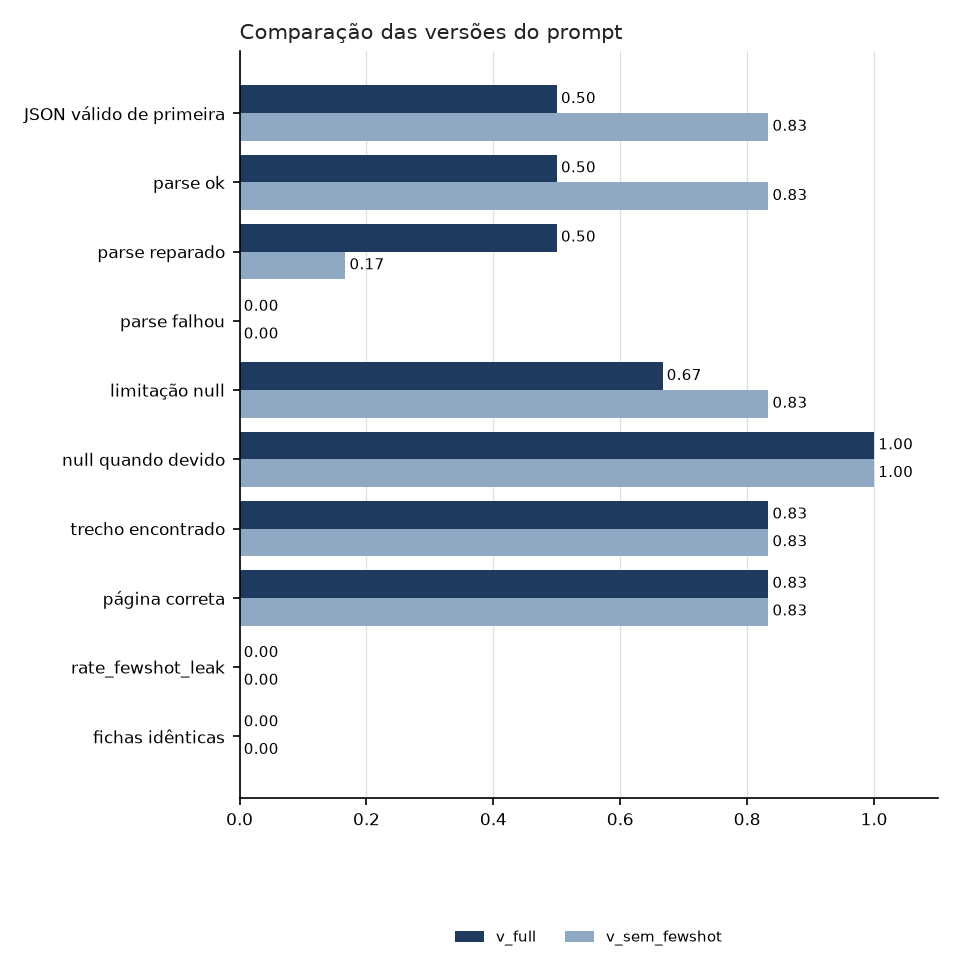

In [11]:
from ficha.audit import compare_prompt_variants
from ficha.report.figures import plot_prompt_comparison

comparacao = compare_prompt_variants(
    execucoes["principal"].records, execucoes["prompt_alt"].records,
    limitacao_gabarito=GABARITO_LIMITACAO,
)
tabela_prompts = comparacao.to_frame()
display(tabela_prompts)
from ficha.report.assemble import prompt_conclusion

veredito = comparacao.decide()
print("Vencedora:", veredito.winner, "—", veredito.explanation)
print(prompt_conclusion(comparacao))  # inclui o trade-off few-shot × vazamento
divergencias = pd.DataFrame([d.to_dict() for d in comparacao.disagreements()])
display(divergencias.head(10) if not divergencias.empty else "As fichas das duas versões não discordam.")

taxas = tabela_prompts.loc[[i for i in tabela_prompts.index if str(i).startswith("rate_")],
                           list(comparacao.variants)].astype(float)
fig_prompts = plot_prompt_comparison(taxas, FIG_DIR / "comparacao_prompts.png")
display(Image(filename=str(fig_prompts)))
# Versão compacta (só as taxas decisivas) para caber no relatório de 3 páginas.
chave = ["rate_json_valid_first_try", "rate_null_when_expected", "rate_fidelity"]
fig_prompts_relatorio = plot_prompt_comparison(
    taxas.loc[[k for k in chave if k in taxas.index]], FIG_DIR / "comparacao_prompts_relatorio.png"
)

## 8. Auditoria (Seção 4.4)

As quatro verificações, cada uma com números e uma frase de conclusão (ADR 0005).

- **a) Fidelidade** — `evidencia.trecho` é procurado no **texto que foi enviado** ao
  modelo (não no PDF inteiro): substring exata após normalização tipográfica; senão
  `partial_ratio` ≥ 0,90. Também conferimos se a página declarada bate com o marcador
  `[p. N]` onde o trecho está.
- **b) Estabilidade** — execução repetida sem mudar nada; diferença campo a campo.
- **c) Efeito da entrada** — `semantic` × `first_pages` nos mesmos artigos.
- **d) Efeito da temperatura** — 0,0 × 0,7 num subconjunto.
- **e) Vazamento de exemplos few-shot** (além do mínimo) — cada campo da ficha é
  comparado com o campo homólogo dos exemplos do prompt (e o trecho, com o texto do
  exemplo). Pega a invenção que a fidelidade não vê: um campo copiado do exemplo com
  trecho de evidência correto.

In [12]:
from ficha.audit import RULE_V1, RULE_V2, build_audit_summary
from ficha.report.assemble import fidelity_block, input_block, stability_block, temperature_block

resumo = build_audit_summary(
    execucoes["principal"].records,
    stability_rep=execucoes["repeticao"].records,
    alt_input=execucoes["entrada_alt"].records,
    t_alt=execucoes["temperatura_alt"].records,
    prompt_runs=(execucoes["principal"].records, execucoes["prompt_alt"].records),
    limitacao_gabarito=GABARITO_LIMITACAO,
    rule=RULE_V2,  # regra final — ver a calibração na seção 9
)
tabelas = resumo.tables()

def mostrar(bloco):
    print(f"{bloco.titulo}: " + " · ".join(f"{k}: {v}" for k, v in bloco.numeros.items()))
    print("→", bloco.conclusao)

mostrar(fidelity_block(resumo))
display(tabelas["fidelidade"])

a) Fidelidade: trecho encontrado: 5/6 (83%) · página correta: 5/6 · exato / aproximado / sem ficha: 5 / 1 / 0
→ 1/6 trecho(s) inventado(s), ausente(s) do texto enviado: artigo_02.


,arquivo,run_id,found,score,method,page_claimed,page_found,page_ok,threshold
0,artigo_01.pdf,20260923-164428_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
1,artigo_02.pdf,20260923-164428_semantic_v_full_t0.0_rep1,False,0.5444,fuzzy,1,NaN,False,0.9
2,artigo_03.pdf,20260923-164428_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
3,artigo_04.pdf,20260923-164428_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
4,artigo_05.pdf,20260923-164428_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9
5,artigo_06.pdf,20260923-164428_semantic_v_full_t0.0_rep1,True,1.0000,exact,1,1.0,True,0.9


Como a fidelidade pega um trecho inventado: o trecho devolvido, o score e o que o texto enviado realmente tinha.

In [13]:
principal = {r.arquivo: r for r in execucoes["principal"].records}
falhas = resumo.fidelity.failures()
for f in falhas[:3]:
    rec = principal[f.arquivo]
    trecho = rec.ficha.evidencia.trecho if rec.ficha else "(sem ficha)"
    print(f"{f.arquivo}: score={f.score:.2f} ({f.method}) — trecho devolvido:\n  «{trecho}»")
    print(f"  início do texto enviado: «{rec.context_text[:300]}...»\n")
if not falhas:
    print("Todos os trechos foram encontrados no texto enviado.")

artigo_02.pdf: score=0.54 (fuzzy) — trecho devolvido:
  «The proposed framework achieves state-of-the-art results across all benchmarks considered.»
  início do texto enviado: «[p. 1]
Aspect-Level Sentiment Classification of Product Reviews

A. Researcher, B. Scientist and C. Analyst · Institute of Data Studies

Abstract

This paper addresses the problem of classifying the sentiment expressed about specific product aspects. A pretrained transformer encoder is fine-tuned wi...»



b) Estabilidade: pares comparados: 6 · fichas idênticas: 6/6 (100%) · campos que mais mudam: nenhum
→ 6/6 fichas idênticas nas duas execuções — esperado com decodificação gulosa e seed fixa. Por isso a variabilidade real do pipeline aparece no efeito da entrada (c) e da temperatura (d), não aqui.


,field,change_rate,mean_similarity
0,problema,0.0,1.0
1,dados,0.0,1.0
2,metodo,0.0,1.0
3,metrica,0.0,1.0
4,limitacao,0.0,1.0
5,evidencia.trecho,0.0,1.0
6,evidencia.pagina,0.0,1.0


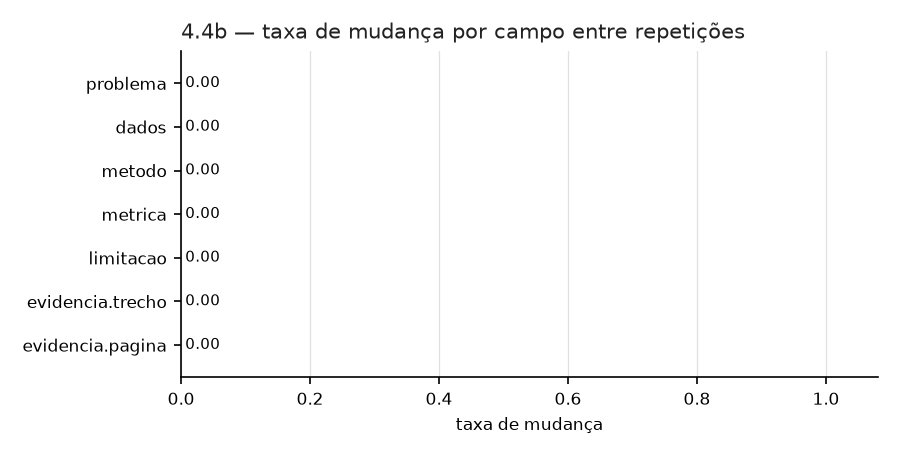

In [14]:
from ficha.report.figures import plot_field_change_rates

mostrar(stability_block(resumo))
display(tabelas["estabilidade_campos"])
fig_estab = plot_field_change_rates(
    tabelas["estabilidade_campos"][["field", "change_rate"]], FIG_DIR / "estabilidade_campos.png",
    title="4.4b — taxa de mudança por campo entre repetições",
)
display(Image(filename=str(fig_estab)))

c) Efeito da entrada: estratégias: semantic × first_pages · fichas idênticas: 0/6 · divergências substantivas: 10 · fidelidade: semantic 83% · first_pages 67% · campos que mais divergem: limitacao 83%, evidencia.trecho 83%, problema 50% · limitacao null: semantic 4/6 · first_pages 3/6
→ Defendemos semantic: semantic vence por maior taxa de fidelidade (0.833 vs 0.667).


,semantic,first_pages
n,6.000000,6.000000
rate_json_valid_first_try,0.500000,0.666667
rate_parse_ok,0.500000,0.666667
rate_parse_repaired,0.500000,0.333333
rate_parse_failed,0.000000,0.000000
rate_limitacao_null,0.666667,0.500000
rate_null_when_expected,1.000000,0.333333
n_null_expected,3.000000,3.000000
rate_fidelity,0.833333,0.666667
rate_page_ok,0.833333,0.666667


,field,change_rate,mean_similarity
0,limitacao,0.833333,0.166667
1,evidencia.trecho,0.833333,0.501400
2,metodo,0.500000,0.923550
3,problema,0.500000,0.928550
4,dados,0.000000,1.000000
5,metrica,0.000000,1.000000
6,evidencia.pagina,0.000000,1.000000


,arquivo,field,a,b,equal,similarity
0,artigo_01.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
1,artigo_01.pdf,evidencia.trecho,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3711
2,artigo_02.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
3,artigo_02.pdf,evidencia.trecho,The proposed framework achieves state-of-the-art results across all benchmarks considered.,Additional experiments confirmed that the conclusions are consistent across random initializations of the network.,False,0.4118
4,artigo_03.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
5,artigo_03.pdf,evidencia.trecho,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,The proposed framework achieves state-of-the-art results across all benchmarks considered.,False,0.3761
6,artigo_04.pdf,limitacao,NaN,O tamanho reduzido da amostra limita a generalização dos resultados.,False,0.0000
7,artigo_04.pdf,evidencia.trecho,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,Our implementation follows established recommendations for hyperparameter optimization and early stopping.,False,0.4541
8,artigo_05.pdf,limitacao,O tamanho reduzido da amostra limita a generalização dos resultados.,NaN,False,0.0000
9,artigo_06.pdf,evidencia.trecho,The organizational context in which predictions are consumed influences the choice of decision thresholds.,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of forecasting traffic speed on ...,False,0.3953


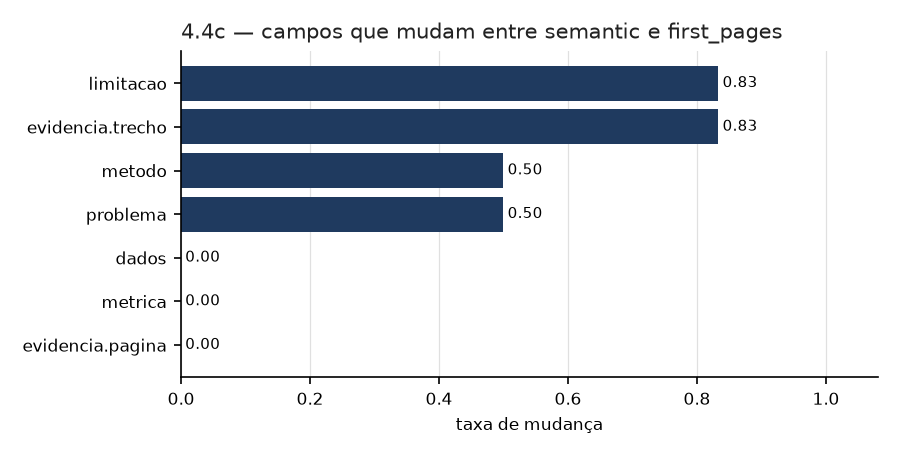

In [15]:
mostrar(input_block(resumo))
display(tabelas["entrada_estrategias"])
display(tabelas["entrada_campos"])
display(tabelas["entrada_divergencias"].head(10))
fig_entrada = plot_field_change_rates(
    tabelas["entrada_campos"][["field", "change_rate"]], FIG_DIR / "entrada_campos.png",
    title=f"4.4c — campos que mudam entre {ESTRATEGIA} e {ESTRATEGIA_ALT}",
)
display(Image(filename=str(fig_entrada)))

**Comparação a três (validação a jusante do ADR 0002).** A estratégia principal, a
alternativa da 4.4c e o experimento, lado a lado, lidos das execuções gravadas. Mais
frases de limitação no contexto só importam se virarem `limitacao` **legítima**:
preenchida, que não é sentinela ("Não informado") nem cópia do exemplo few-shot. A
conclusão usa o critério declarado da 4.4c (taxa de página correta).

In [16]:
from ficha.report.assemble import strategy_comparison, strategy_verdict

runs_estrategias = {
    f"{ESTRATEGIA} (principal)": execucoes["principal"].records,
    f"{ESTRATEGIA_ALT} (alternativa 4.4c)": execucoes["entrada_alt"].records,
}
if "experimento" in extras:
    runs_estrategias[f"{EXPERIMENTO} (experimento)"] = extras["experimento"].records
recall_por_estrategia = recall if recall_table is not None else None
comparacao_estrategias = strategy_comparison(runs_estrategias, recall_por_estrategia)
display(comparacao_estrategias)
ANTES_DEPOIS = strategy_verdict(
    comparacao_estrategias, f"{ESTRATEGIA} (principal)", f"{EXPERIMENTO} (experimento)",
    recall_por_estrategia,
)
print(ANTES_DEPOIS or "Sem execução do experimento gravada para comparar.")

,estrategia,fichas_ok,n,fidelidade,pagina_correta,vazamento,limitacao_preenchida,limitacao_legitima,limitacao_vazada,limitacao_sentinela,tokens_entrada,recall_limitacoes_no_contexto,legitimas
0,semantic (principal),6,6,5,5,0,2,2,0,0,21502,0.667,"artigo_03, artigo_05"
1,first_pages (alternativa 4.4c),6,6,4,4,0,3,3,0,0,25816,1.000,"artigo_01, artigo_02, artigo_04"
2,hybrid (experimento),6,6,2,2,0,4,4,0,0,26525,1.000,"artigo_01, artigo_02, artigo_03, artigo_04"


Corrigimos a entrada — artigos com limitação declarada no contexto: 2 → 3 de 3; recall das frases 67% → 100%. E a saída melhorou: limitacao legítima 2/6 (artigo_03, artigo_05) × 4/6 (artigo_01, artigo_02, artigo_03, artigo_04); no hybrid (experimento), 0 preenchida(s) copiada(s) do exemplo e 0 sentinela. Pelo critério declarado da 4.4c (pagina correta: 5/6 × 2/6; tokens de entrada +23% no hybrid (experimento)), a estratégia final é semantic.


In [17]:
mostrar(temperature_block(resumo))
print("Critério declarado:", resumo.temperature.criterio)
display(tabelas["temperatura"])

d) Efeito da temperatura: subconjunto: 3 artigos · JSON válido de primeira: t=0,0: 33% · t=0,7: 67% · fidelidade: t=0,0: 67% · t=0,7: 0% · fichas idênticas: 0/3
→ Pelo critério declarado, t=0,0 não se sustenta neste subconjunto: t=0,7 teve fidelidade 0% vs 67% em t=0,0. Erro(s) em t=0,0: artigo_02. Com n=3 artigos, a diferença não sustenta conclusão. Mantemos t=0,0 pela estabilidade (6/6 fichas idênticas entre repetições) e reportamos o resultado como está.
Critério declarado: A temperatura escolhida se sustenta se, no mesmo subconjunto de artigos, tiver taxa de fidelidade (trecho encontrado no texto enviado) maior ou igual e taxa de JSON válido de primeira maior ou igual às da temperatura alternativa.


,t=0.0,t=0.7
n,3.000000,3.000000
rate_json_valid_first_try,0.333333,0.666667
rate_parse_ok,0.333333,0.666667
rate_parse_repaired,0.666667,0.333333
rate_parse_failed,0.000000,0.000000
rate_limitacao_null,0.666667,0.333333
rate_null_when_expected,0.000000,0.000000
n_null_expected,1.000000,1.000000
rate_fidelity,0.666667,0.000000
rate_page_ok,0.666667,0.000000


**e) Vazamento de exemplos few-shot.** Execução principal, a execução `semantic`
anterior (quando existe) e a variante sem few-shot — que não pode vazar por construção,
servindo de controle.

In [18]:
from ficha.audit import leakage_summary
from ficha.report.assemble import invention_cases, invention_highlight, leakage_block

runs_vazamento = {f"{ESTRATEGIA} (principal)": execucoes["principal"].records}
if "experimento" in extras:
    runs_vazamento[f"{EXPERIMENTO} (experimento)"] = extras["experimento"].records
runs_vazamento["v_sem_fewshot"] = execucoes["prompt_alt"].records
mostrar(leakage_block(runs_vazamento))
for rotulo, recs in runs_vazamento.items():
    casos = leakage_summary(recs).to_frame()
    if not casos.empty:
        print(f"\n{rotulo}:")
        display(casos[["arquivo", "field", "example_name", "similarity", "method", "value"]])
print("\n" + invention_highlight(invention_cases(runs_vazamento)))

e) Vazamento de exemplos few-shot: semantic (principal): 0/6 · hybrid (experimento): 0/6 · v_sem_fewshot: 0/6
→ Nenhum campo reproduz os exemplos do prompt.

Invenções convincentes detectadas — (1) artigo_02, execução semantic (principal): trecho «The proposed framework achieves state-of-the-art results across all benchmarks considered.» ausente do texto enviado. Detectado pela fidelidade, que compara com o texto efetivamente enviado ao modelo. (2) artigo_01, execução hybrid (experimento): trecho «The proposed framework achieves state-of-the-art results across all benchmarks considered.» ausente do texto enviado. Detectado pela fidelidade, que compara com o texto efetivamente enviado ao modelo. Outros 3 caso(s) nas tabelas das verificações a) e e).


## 9. Confiança — regra declarada e fichas que não defenderíamos

`confianca` nunca vem do modelo nem "do olho": é função determinística das verificações
acima (`ficha.audit.ConfidenceRule`). Cada ficha carrega os **motivos** que a
impediram de ter nível mais alto — é deles que sai a lista de fichas não defensáveis.

**Duas versões da regra, e por que a final é a v2.** A v1 (estrita) rebaixava uma ficha
se *qualquer* campo mudasse entre as duas estratégias de entrada. Os dados mostram que
isso mede redação, não confiabilidade: entre estratégias, a similaridade média dos
campos de texto livre fica em torno de 0,5 (entradas diferentes produzem paráfrases e
evidências de outras páginas por construção), enquanto entre repetições com a mesma
entrada é 1,00. A v2 compara estratégias só pela **discordância categórica** — a
limitação declarada numa e `null` na outra — e mantém a comparação exata entre
repetições. A tabela abaixo mostra as duas distribuições lado a lado; a tabela final e
o PDF usam a v2. A calibração foi decidida depois de ver os dados reais, e isso é
declarado aqui e no relatório.

In [19]:
from ficha.audit import build_final_fichas, confidence_distribution
from ficha.report.assemble import mean_text_similarity

args_regra = (execucoes["principal"].records, execucoes["repeticao"].records,
              execucoes["entrada_alt"].records)
DISTRIBUICOES = {
    "v1 estrita": confidence_distribution(build_final_fichas(*args_regra, RULE_V1)),
    "v2 categórica (final)": confidence_distribution(build_final_fichas(*args_regra, RULE_V2)),
}
display(pd.DataFrame(DISTRIBUICOES).rename_axis("confianca"))
sim_entrada = mean_text_similarity(resumo.input_effect.diff.field_mean_similarity)
sim_repeticao = mean_text_similarity(resumo.stability.diff.field_mean_similarity)
print(f"Similaridade média dos campos de texto livre: entre estratégias {sim_entrada:.2f} · "
      f"entre repetições {sim_repeticao:.2f}")

,v1 estrita,v2 categórica (final)
confianca,,
alta,0,1
media,2,4
baixa,4,1


Similaridade média dos campos de texto livre: entre estratégias 0.87 · entre repetições 1.00


Regra de confiança v2 (aplicada automaticamente; o nível final é o MENOR entre os limites abaixo):
- BAIXA se a extração falhou (nenhum JSON válido segundo o esquema), ou o trecho de evidência não foi encontrado no texto enviado ao modelo (similaridade partial_ratio normalizada < 0.90), ou o trecho foi encontrado numa página diferente da declarada em evidencia.pagina, ou algum campo textual (problema, dados, metodo, metrica, limitacao, evidencia.trecho) reproduz o campo homólogo de um exemplo few-shot do prompt (similaridade ≥ 0.80; trecho também contra o texto do exemplo), ou algum campo contém um termo de domínio exclusivo dos exemplos (fraude, chargeback, supermercados, vendas, WMAPE, suavização exponencial...) cujo equivalente em inglês não aparece no texto enviado — cópia do exemplo é invenção, mesmo quando o trecho passa na fidelidade, ou mais de 2 campos mudaram entre as duas repetições (mesma entrada).
- MEDIA se a evidência passou, mas entre 1 e 2 campos mudaram entre as repet

,confianca,n
0,alta,1
1,media,4
2,baixa,1


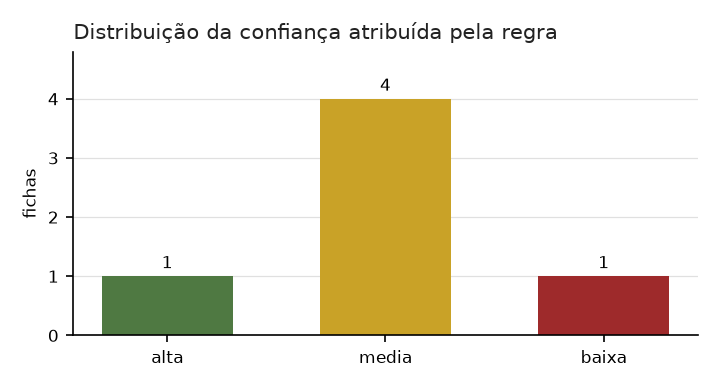

Fichas que NÃO defenderíamos (confiança baixa) e por quê:


,arquivo,confianca,motivos
0,artigo_02.pdf,baixa,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; discordância categórica entre...


In [20]:
from ficha.report.figures import plot_confidence_distribution

print(resumo.rule.describe())
display(tabelas["confianca"])
fichas_finais = [f.ficha for f in resumo.fichas]
fig_conf = plot_confidence_distribution(fichas_finais, FIG_DIR / "distribuicao_confianca.png")
display(Image(filename=str(fig_conf)))
print("Fichas que NÃO defenderíamos (confiança baixa) e por quê:")
display(tabelas["nao_defensaveis"])

In [21]:
colunas = ["arquivo", "confianca", "limitacao", "evidencia_pagina", "audit_motivos",
           "audit_fidelity_score", "audit_campos_instaveis", "audit_campos_divergentes_entrada"]
display(tabelas["fichas"][colunas])

,arquivo,confianca,limitacao,evidencia_pagina,audit_motivos,audit_fidelity_score,audit_campos_instaveis,audit_campos_divergentes_entrada
0,artigo_01.pdf,media,NaN,1,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra,1.0000,,limitacao
1,artigo_02.pdf,baixa,NaN,1,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; discordância categórica entre...,0.5444,,limitacao
2,artigo_03.pdf,media,O tamanho reduzido da amostra limita a generalização dos resultados.,1,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra; limitação preench...,1.0000,,limitacao
3,artigo_04.pdf,media,NaN,1,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra,1.0000,,limitacao
4,artigo_05.pdf,media,O tamanho reduzido da amostra limita a generalização dos resultados.,1,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra,1.0000,,limitacao
5,artigo_06.pdf,alta,NaN,1,"trecho encontrado (exact, score 1.00) na página declarada p. 1; estável entre repetições e estratégias",1.0000,,


## 10. Custo (Seção 4.5)

Somamos o `Usage` de **todas** as chamadas feitas — todas as execuções gravadas em
`data/runs`, inclusive repetição, prompt alternativo, entrada alternativa, temperatura
e **o experimento `hybrid`** (a Seção 4.5 pede tudo o que foi enviado). A alternativa
ingênua espelha exatamente as mesmas chamadas, trocando o texto selecionado pelo
artigo inteiro. Mesmo com o modelo local gratuito, a premissa de preço (visível abaixo)
responde "quanto isso custaria" num provedor pago.

In [22]:
from ficha.cost import (PricePremise, compare_costs, cost_by_run, cost_of_records,
                        cost_table, naive_cost_from_records)

premissa = PricePremise.from_settings(settings)
# Tudo o que foi efetivamente enviado ao modelo: todas as execuções gravadas em data/runs
# (inclusive as da estratégia anterior), não só as usadas na auditoria final.
todos = []
for run_id in store.list_runs():
    try:
        todos += store.load(run_id)
    except (FileNotFoundError, ValueError) as exc:  # execução ainda sendo gravada
        print(f"custo: {run_id} ignorado ({type(exc).__name__})")
custo_real = cost_of_records(todos, premissa, label="real (todas as execuções)")
custo_ingenuo = naive_cost_from_records(todos, docs, count_tokens, premissa)
comparacao_custo = compare_costs(custo_real, custo_ingenuo)
custo_por_execucao = cost_by_run(todos, premissa)
print(premissa.describe())
display(cost_table([*custo_por_execucao, custo_real, custo_ingenuo]))
print(comparacao_custo.describe())

Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


,label,n_calls,input_tokens,output_tokens,total_tokens,usd_input,usd_output,usd_total,premissa
0,20260923-164428_first_pages_v_full_t0.0_rep1,6,25816,674,26490,0.077448,0.010110,0.087558,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
1,20260923-164428_hybrid_v_full_t0.0_rep1,6,26525,666,27191,0.079575,0.009990,0.089565,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
2,20260923-164428_semantic_v_full_t0.0_rep1,6,21502,661,22163,0.064506,0.009915,0.074421,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
3,20260923-164428_semantic_v_full_t0.0_rep2,6,21502,661,22163,0.064506,0.009915,0.074421,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
4,20260923-164428_semantic_v_full_t0.7_rep1,3,10690,346,11036,0.032070,0.005190,0.037260,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
5,20260923-164428_semantic_v_sem_fewshot_t0.0_rep1,6,16568,634,17202,0.049704,0.009510,0.059214,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
6,real (todas as execuções),33,122603,3642,126245,0.367809,0.054630,0.422439,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
7,"ingênuo (artigo inteiro, mesmas chamadas)",33,147729,3642,151371,0.443187,0.054630,0.497817,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."


Enviar o artigo inteiro custaria US$ 0.4978 contra US$ 0.4224 efetivamente gastos: 1.2x mais caro (1.2x mais tokens de entrada). Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


## 11. Tabela comparativa (entregável 2)

Uma linha por artigo, com **todos** os campos da ficha na ordem da Seção 3, mais a
coluna `motivos_confianca`. CSV em UTF-8 com BOM (abre certo no Excel pt-BR) e XLSX
formatado. `limitacao = null` vira célula vazia.

In [23]:
from ficha.report import delivery_basename, write_table

BASENAME = delivery_basename(INTEGRANTES)
extras = {f.arquivo: {"motivos_confianca": f.motivos} for f in resumo.fichas}
saidas = write_table(fichas_finais, settings.outputs_dir, basename=BASENAME, extras=extras)
print("CSV :", saidas.csv)
print("XLSX:", saidas.xlsx)
display(pd.read_csv(saidas.csv, encoding="utf-8-sig").head())

CSV : /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.csv
XLSX: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.xlsx


,arquivo,problema,dados,metodo,metrica,limitacao,evidencia_trecho,evidencia_pagina,confianca,motivos_confianca
0,artigo_01.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,1 Introduction\n\nWe study the problem of forecasting hospital readmission within thirty days of discharge.,1,media,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra
1,artigo_02.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,The proposed framework achieves state-of-the-art results across all benchmarks considered.,1,baixa,trecho não encontrado no texto enviado (score 0.54 < 0.90): possível trecho inventado; discordância categórica entre...
2,artigo_03.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,O tamanho reduzido da amostra limita a generalização dos resultados.,Analyst · Institute of Data Studies\n\nAbstract\n\nThis paper addresses the problem of predicting default of credit ...,1,media,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra; limitação preench...
3,artigo_04.pdf,Resolver o problema descrito no artigo.,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo.,Métrica reportada nos resultados.,NaN,Several contributions rely on handcrafted representations whose generalization to unseen institutions remains questi...,1,media,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra
4,artigo_05.pdf,Resolver o problema descrito no artigo (variante 4).,Dados descritos na seção de dados do artigo.,Método principal descrito no artigo (variante 4).,Métrica reportada nos resultados.,O tamanho reduzido da amostra limita a generalização dos resultados.,Performance is measured by the concordance index (C-index) and the integrated Brier score.,1,media,discordância categórica entre estratégias de entrada: limitacao é null numa e preenchida na outra


## 12. Relatório PDF (entregável 3, ≤ 3 páginas)

O relatório é montado **a partir dos objetos acima** (`ficha.report.assemble`): nenhum
número é digitado à mão. Os textos de justificativa vêm de `Narrative` (resumo dos
ADRs); depois de ler os resultados reais, o grupo revisa e sobrescreve o que quiser —
inclusive as conclusões de cada verificação (`Narrative(conclusoes={...})`). A geração
conta as páginas e falha alto se passar de 3.

In [24]:
from ficha.report import build_report_pdf, count_pages
from ficha.report.assemble import Narrative, build_report_content
from ficha.report.pdf import ReportTooLongError

estrategia_textos = {}
if ESTRATEGIA == "semantic" and ANTES_DEPOIS:
    estrategia_textos = dict(
        estrategia_escolhida=(
            "semantic — blocos por similaridade dentro do próprio artigo (first_pages "
            "como alternativa da 4.4c; hybrid testado como experimento e descartado)"
        ),
        estrategia_justificativa=(
            "Blocos de 1.200 caracteres (~300 tokens, um parágrafo típico) com "
            "sobreposição de 200 (uma frase inteira, para não cortar a evidência); 8 "
            "consultas em português, uma ou duas por campo, embedder multilíngue, blocos "
            "reordenados por página. Como limitacao veio null em quase todas as fichas, "
            "testamos o hybrid, que prioriza janelas de limitação: " + ANTES_DEPOIS
        ),
    )
narrativa = Narrative(  # edite aqui; conclusoes={"fidelidade": "..."} sobrescreve blocos
    **estrategia_textos,
    cobertura_limitacao=" ".join(
        t for t in (COBERTURA_LIMITACAO, ORCAMENTO_HYBRID, CIRCULARIDADE) if t
    ),
    antes_depois=(
        f"Experimento {EXPERIMENTO} × {ESTRATEGIA}: comparação a três na seção 1."
        if estrategia_textos else ANTES_DEPOIS
    ),
    # Casos em destaque no PDF: um pego pela fidelidade, outro só pelo vazamento.
    destaques_preferidos=["08_Leka", "06_Barnes"] if MODO == "real" else [],
    nota_limitacao=(
        "Sem gabarito manual não dá para separar abstenção correta de omissão; a "
        "heurística de vocabulário de limitação teve falsos positivos confirmados "
        "(título 'Scope, and Limitations'; parágrafo sobre limitações da IA "
        "generativa) e por isso não entra na regra."
    ) if MODO == "real" else "",
)
gpu = describe_gpu()
MODELO_DECLARADO = client.model_name + (f" · {gpu['nome']}" if gpu else "")
if MODO == "ensaio":
    MODELO_DECLARADO += " (MODO ENSAIO: FakeLLM + PDFs sintéticos — não é resultado)"

def montar(custo_detalhado):
    return build_report_content(
        integrantes=INTEGRANTES,
        modelo=MODELO_DECLARADO,
        summary=resumo,
        cost=comparacao_custo,
        cost_per_run=custo_por_execucao if custo_detalhado else None,
        strategy_table=resumo_estrategias[["caracteres_medios", "tokens_medios", "tokens_corpus"]],
        narrative=narrativa,
        figuras=[fig_prompts_relatorio],
        rule_distributions=DISTRIBUICOES,
        leak_runs=runs_vazamento,
    )

pdf_path = settings.outputs_dir / f"{BASENAME}.pdf"
try:
    try:
        build_report_pdf(montar(custo_detalhado=True), pdf_path)
    except ReportTooLongError:
        # Limite de 3 páginas: a tabela de custo cai para os totais (o detalhe por
        # execução continua na seção 10 deste notebook).
        build_report_pdf(montar(custo_detalhado=False), pdf_path)
        print("Custo no PDF reduzido aos totais para caber em 3 páginas.")
    print(f"PDF: {pdf_path} · {count_pages(pdf_path)} página(s)")
except ReportTooLongError as exc:
    print("ATENÇÃO — relatório longo demais, encurte a narrativa:", exc)

PDF: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/ensaio/outputs/AtividadeI_SOBRENOMES.pdf · 3 página(s)


## 13. Checklist de entrega

- [ ] `MODO = "real"` e os 19 PDFs em `data/raw` (a tabela da seção 3 mostra 19 linhas).
- [ ] Integrantes preenchidos na **primeira célula** e em `INTEGRANTES`; o PDF traz os
      nomes na primeira página.
- [ ] Os três arquivos nomeados `AtividadeI_<sobrenomes>`: este notebook (renomeie o
      `.ipynb`), `data/outputs/AtividadeI_<sobrenomes>.csv`/`.xlsx` e `.pdf`.
- [ ] **Ambiente de execução → Reiniciar e executar tudo**, sem erro, com as saídas
      visíveis — só então baixar o `.ipynb`.
- [ ] O PDF tem no máximo 3 páginas (a seção 12 imprime o número).
- [ ] Nenhuma chave no notebook: só Secrets do Colab/variáveis de ambiente (a célula de
      setup imprime apenas se a chave existe).
- [ ] As conclusões do relatório foram revisadas pelo grupo em `Narrative(...)` e cada
      frase é defensável com um número deste notebook.
- [ ] As saídas brutas (`data/runs/`) foram guardadas.